# 04 — Comparison & Live Viewer

Compares all four agents (random / greedy / DQN / N-tuple) using the JSON eval files written by Notebooks 01–03. Renders the training dashboard and plays a live game from any saved checkpoint.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, Image

from src.utils import set_seed, pick_device, CKPT_DIR, LOG_DIR, EVAL_DIR, GIF_DIR
from src.agents.random_agent import RandomAgent
from src.agents.greedy_agent import GreedyAgent
from src.agents.dqn import DQNAgent
from src.agents.ntuple import NTupleAgent
from src.eval.report import build_comparison
from src.viz.dashboard import plot_training, plot_tile_distribution
from src.viz.viewer import play_game, compare_side_by_side

set_seed(42)
sns.set_theme()
plt.rcParams['figure.dpi'] = 110
DEVICE = pick_device()

## 1. Aggregate eval results

In [2]:
eval_paths = {
    'random':  EVAL_DIR / 'eval_random.json',
    'greedy':  EVAL_DIR / 'eval_greedy.json',
    'dqn':     EVAL_DIR / 'eval_dqn.json',
    'ntuple':  EVAL_DIR / 'eval_ntuple.json',
}
train_logs = {
    'dqn':    LOG_DIR / 'dqn.csv',
    'ntuple': LOG_DIR / 'ntuple.csv',
}
df = build_comparison(eval_paths, train_logs, EVAL_DIR)
df

,agent,mean_score,median_score,max_score,mean_max_tile,max_max_tile,mean_steps,pct_>=512,pct_>=1024,pct_>=2048,pct_>=4096,pct_>=8192
3,ntuple,3270.166667,3178.0,7414,1221.973333,4096,1086.803333,0.983333,0.870000,0.25,0.006667,0.0
1,greedy,1299.586667,1265.5,3067,468.266667,1024,448.490000,0.646667,0.106667,0.00,0.000000,0.0
2,dqn,310.550000,295.5,644,109.440000,256,123.560000,0.000000,0.000000,0.00,0.000000,0.0
0,random,297.584000,291.0,733,107.584000,256,118.988000,0.000000,0.000000,0.00,0.000000,0.0


## 2. Training dashboard

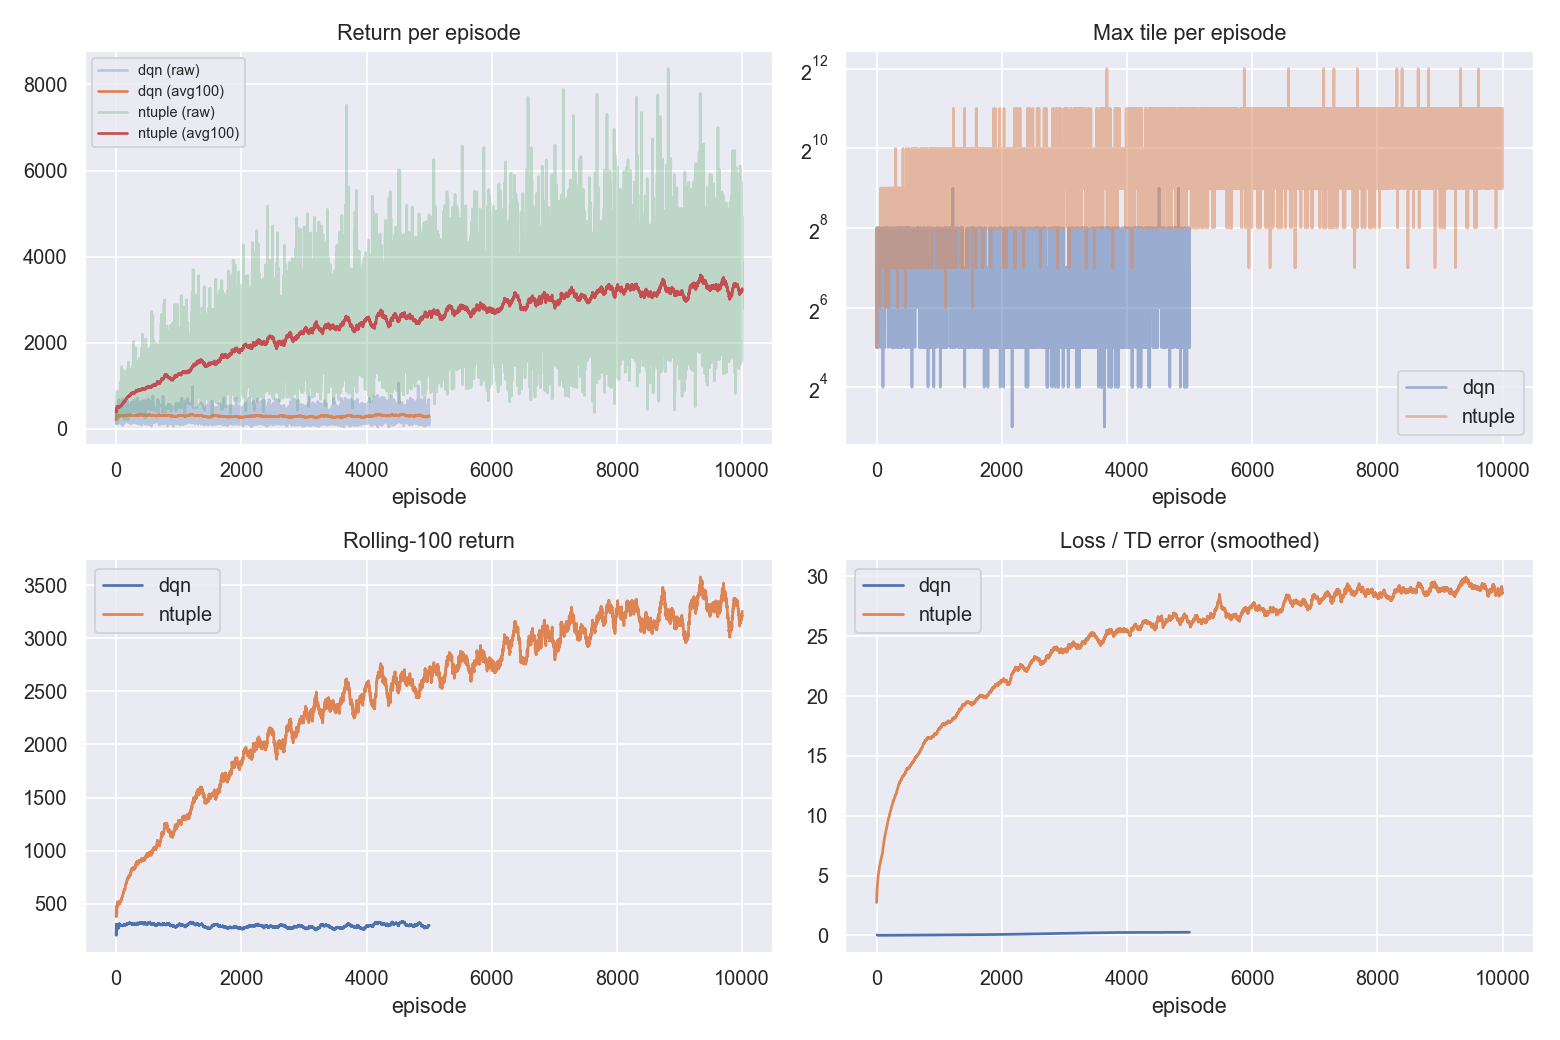

In [3]:
dash = plot_training(train_logs, EVAL_DIR)
Image(dash)

## 3. Tile-reach distribution

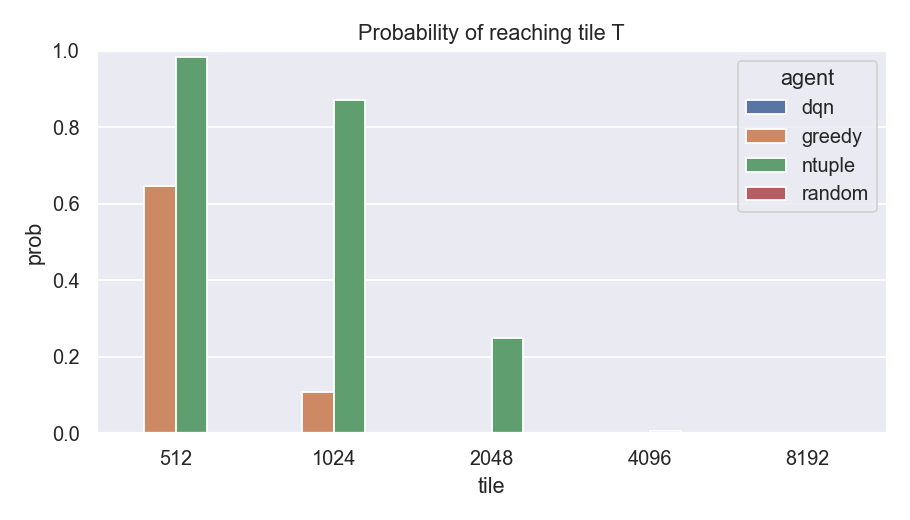

In [4]:
tile_dist = plot_tile_distribution(eval_paths, EVAL_DIR)
Image(tile_dist)

## 4. Live game viewer
Plays one greedy game and renders it as an inline animation. Replace the agent / checkpoint to inspect any policy.

In [5]:
agent = NTupleAgent(alpha=0.1)
ckpt = CKPT_DIR / 'ntuple' / 'latest.npz'
if ckpt.exists():
    gif_path, anim = play_game(agent, ckpt, save_gif=True, fps=4, seed=42)
    print('saved:', gif_path)
    HTML(anim.to_jshtml())

saved: /Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/Assignment 5/data/gifs/ntuple_42.gif


Animation size has reached 20979528 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


## 5. Side-by-side: DQN vs N-tuple
Same initial board, two policies, played in lockstep until both end.

In [6]:
dqn_ckpt = CKPT_DIR / 'dqn' / 'latest.pt'
nt_ckpt  = CKPT_DIR / 'ntuple' / 'latest.npz'
if dqn_ckpt.exists() and nt_ckpt.exists():
    a_dqn = DQNAgent(device=DEVICE)
    a_nt = NTupleAgent(alpha=0.1)
    gif_path, anim = compare_side_by_side(a_dqn, a_nt, ckpt_a=dqn_ckpt, ckpt_b=nt_ckpt,
                                           sync_seed=42, fps=4)
    print('saved:', gif_path)
    HTML(anim.to_jshtml())

saved: /Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/Assignment 5/data/gifs/compare_dqn_vs_ntuple.gif


Animation size has reached 21012769 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


## 6. Summary

Reading the comparison table together with the training curves, the headline result is the gap between the **N-tuple** value function and the **DQN** under matched training budgets. The DQN learns a generic features-from-pixels representation; the N-tuple is given the corner+row+square symmetry structure of the game for free. On 2048, where success hinges on detecting a small set of geometrically meaningful patterns, the latter dominates — even though it is a *linear* function approximator. Notebook outputs above and the figures in `data/eval/` are the source of the writeup in `writeup/analysis.md`.